In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ls ../../

Invalid switch - "..".


In [10]:
# Gather all the text files for Essays
essay_folder = "../../data/eval/texts/test_essay/"
essay_files = [f for f in os.listdir(essay_folder) if f.endswith(".txt")]
essay_dict = {}

for file in essay_files:
    file_path = os.path.join(essay_folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        essay_dict[file] = content

essay_dict

{'Essay_C2_Masterclass_Response_A.txt': 'It cannot be denied that tourism is an economic force \nand that over the past decades it has gone from strength \nto strength. Both texts give us some insight into one \nimportant link for the industry, and that is the internet. \nThe first text makes it clear that travel, whether doing \nso on a restricted budget or with no such limitations, is \nfacilitated with the amount of online material to choose \nfrom. This may, of course, include such things as travel \nvlogs, such as the ones produced by the author of the \nsecond article. This second author writes from a personal \nviewpoint and her perspective confirms that the world \nwide web is indeed a rich resource. \nReading between the lines, the travel vlogger appears \nto show her passion and extraordinary enthusiasm for \ntravel. This is somewhat missing in the first text where \nthe process of identifying where to go and what to do is \nmade to sound so much more mechanical. The vlogger 

In [11]:
fiction_folder = "../../data/eval/texts/test_fiction/"
fiction_files = [f for f in os.listdir(fiction_folder) if f.endswith(".txt")]
fiction_dict = {}

for file in fiction_files:
    file_path = os.path.join(fiction_folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        fiction_dict[file] = content
fiction_dict

{'LotR_Chapter_1.txt': 'Chapter 1\n\nA LONG-EXPECTED PARTY\n\nWhen Mr. Bilbo Baggins of Bag End announced that he\nwould shortly be celebrating his eleventy-ﬁrst birthday with\na party of special magniﬁcence, there was much talk and\nexcitement in Hobbiton.\nBilbo was very rich and very peculiar, and had been the\nwonder of the Shire for sixty years, ever since his remarkable\ndisappearance and unexpected return. The riches he had\nbrought back from his travels had now become a local legend,\nand it was popularly believed, whatever the old folk might\nsay, that the Hill at Bag End was full of tunnels stuffed with\ntreasure. And if that was not enough for fame, there was also\nhis prolonged vigour to marvel at. Time wore on, but it\nseemed to have little effect on Mr. Baggins. At ninety he was\nmuch the same as at ﬁfty. At ninety-nine they began to call\nhim well-preserved; but unchanged would have been nearer the\nmark. There were some that shook their heads and thought\nthis was too m

In [ ]:
# Continue here...

In [26]:
sns.set_theme(style="whitegrid", palette="muted")

data = []
file_path = "../../reports/eval_results.jsonl" 

try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line.strip()))
except FileNotFoundError:
    print(f"Could not find the file at: {file_path}")

df = pd.DataFrame(data)

df_retrieval = df[df['eval_type'] == 'retrieval'].copy()
df_generation = df[df['eval_type'] == 'generation'].copy()

print(f"Loaded {len(df)} total evaluation runs.")
display_cols = ['eval_type', 'llm_model', 'embedding_model', 'average_score', 'duration_seconds', 'ram_gb']

display(df[display_cols].sort_values(by=['eval_type', 'average_score'], ascending=[True, False]))

Loaded 4 total evaluation runs.


,eval_type,llm_model,embedding_model,average_score,duration_seconds,ram_gb
1,generation,llama3.1:8b,nomic-embed-text,0.9000,421.08,8.6
2,generation,mistral:latest,nomic-embed-text,0.7667,218.41,8.6
0,retrieval,llama3.1:8b,nomic-embed-text,0.2250,1746.16,8.6
3,retrieval,llama3.1:8b,all-MiniLM-L6-v2,0.0715,1238.47,8.6


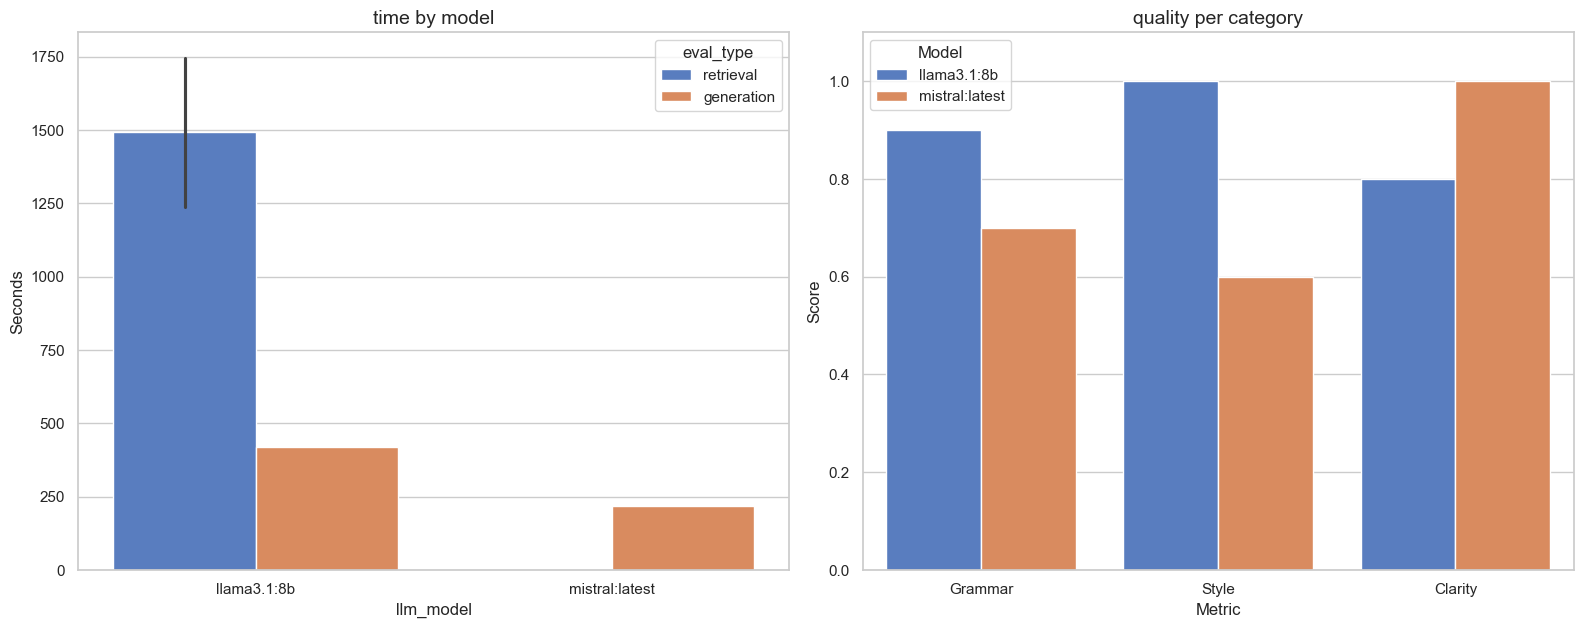

In [28]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df, x='llm_model', y='duration_seconds', hue='eval_type', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_ylabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_generation.empty:
    gen_metrics = []
    for _, row in df_generation.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()